# 04 · Clasificación de abandono: probabilidades, reglas y decisiones de campaña

**Edición docente · 8 de octubre de 2026 · Modelos Predictivos en Negocios**

**Unidad 2 · Semana 5 · RA2 (CE 2.3–2.6) · 150–180 minutos.**
Compararás regresión logística, árbol, KNN y bosque aleatorio para FinCordillera; interpretarás razones de chances y reglas; medirás ordenamiento con AUC, KS y Gini; y traducirás puntajes a una campaña con supuestos explícitos.

**Cómo trabajar:** ejecuta desde la primera celda. Antes de mover un control, escribe qué esperas que ocurra;
después compara y justifica la diferencia. Los casos son docentes: FinCordillera, QuillayMarket y PulpaLenga son
empresas ficticias con datos simulados del repositorio; las simulaciones adicionales se identifican como tales.

Los controles requieren JupyterLab con `ipywidgets` y un kernel activo; las salidas guardadas permiten leer los
resultados sin ejecutar. Cada función interactiva también puede llamarse directamente con argumentos.

[Guía maestra](../guia_maestra_mpn.html) · [Manual científico](../material_propio/MPN_manual_cientifico.pdf) ·
[Cobertura curricular](../COBERTURA.md)

In [1]:
from pathlib import Path
import sys
import warnings
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "_transversal" / "datos").is_dir()), None)
if RAIZ is None:
    raise FileNotFoundError("Abra Jupyter desde el repositorio completo o una subcarpeta.")
CURSO = RAIZ / "03_Modelos_Predictivos_Negocios"
sys.path.insert(0, str(CURSO / "reproducibilidad"))
import mpn_recursos as mr
from mpn_recursos import pregunta, SEMILLA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
%matplotlib inline
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .18, "font.size": 10})
pd.set_option("display.max_columns", 16)
pd.set_option("display.float_format",
              lambda v: f"{v:,.0f}" if abs(v) >= 1e4 or float(v).is_integer() else f"{v:,.3f}")
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · semilla {SEMILLA}")

Python 3.12.13 · pandas 3.0.6 · semilla 2026


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, average_precision_score

banco = mr.fincordillera_clientes()
X = banco.drop(columns=["cliente_id", "churn"])
y = banco["churn"]
numericas = X.select_dtypes("number").columns.tolist()
categoricas = ["region"]
Xe, Xv, Xt, ye, yv, yt = mr.particion_tres(X, y)
print(f"Entrenamiento {len(ye)} · validación {len(yv)} · prueba {len(yt)} · tasa base {y.mean():.1%}")

Entrenamiento 570 · validación 190 · prueba 190 · tasa base 28.0%


<a id="logistica"></a>

## Regresión logística: probabilidades y razones de chances

La logística modela el logaritmo de las chances (*log-odds*) como función lineal:

$$\log\frac{p(x)}{1-p(x)} = \beta_0 + \beta^\top x \quad\Longleftrightarrow\quad p(x) = \frac{1}{1+e^{-(\beta_0+\beta^\top x)}}.$$

$e^{\beta_j}$ es la **razón de chances** (*odds ratio*): cuánto se multiplican las chances del evento cuando $x_j$
aumenta una unidad, con lo demás fijo. Con variables estandarizadas, la unidad es una desviación estándar. El control
muestra la curva sigmoide para una sola variable (reclamos).

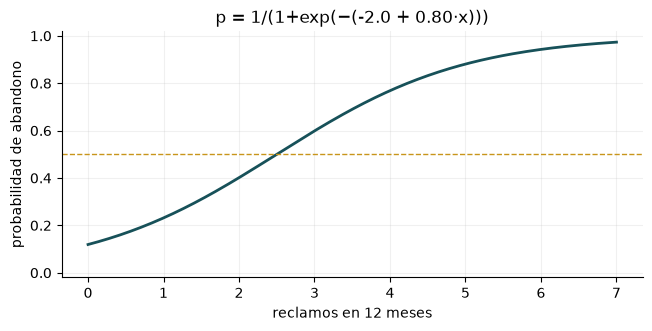

Cada reclamo multiplica las chances por 2.23. La probabilidad cruza 0,5 con 2.5 reclamos.

interactive(children=(FloatSlider(value=-2.0, description='intercepto', max=2.0, min=-5.0, step=0.25), FloatSl…

In [3]:
def explorar_sigmoide(intercepto=-2.0, pendiente=0.8):
    x = np.linspace(0, 7, 200)
    p = 1 / (1 + np.exp(-(intercepto + pendiente * x)))
    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    ax.plot(x, p, color="#175159", lw=2); ax.axhline(.5, color="#c8951b", ls="--", lw=1)
    ax.set(xlabel="reclamos en 12 meses", ylabel="probabilidad de abandono", ylim=(-.02, 1.02),
           title=f"p = 1/(1+exp(−({intercepto:.1f} + {pendiente:.2f}·x)))")
    plt.show()
    cruce = -intercepto / pendiente if pendiente != 0 else np.nan
    texto = (f"Cada reclamo multiplica las chances por {np.exp(pendiente):.2f}. "
             + (f"La probabilidad cruza 0,5 con {cruce:.1f} reclamos." if np.isfinite(cruce) else "Sin pendiente no hay cruce."))
    display(Markdown(texto))
    return {"odds_ratio": float(np.exp(pendiente)), "cruce_0_5": float(cruce)}

sigmoide_base = explorar_sigmoide()
widgets.interact(explorar_sigmoide, intercepto=widgets.FloatSlider(value=-2, min=-5, max=2, step=.25),
                 pendiente=widgets.FloatSlider(value=.8, min=-1, max=2, step=.05));

In [4]:
logistica = Pipeline([("preparar", mr.preprocesador(numericas, categoricas)),
                      ("modelo", LogisticRegression(max_iter=2000))]).fit(Xe, ye)
nombres = [n.split("__")[-1] for n in logistica.named_steps["preparar"].get_feature_names_out()]
coeficientes = pd.DataFrame({"coeficiente": logistica.named_steps["modelo"].coef_[0]}, index=nombres)
coeficientes["razón_de_chances"] = np.exp(coeficientes["coeficiente"])
coeficientes["unidad"] = ["+1 desviación estándar" if n in numericas else "frente a Antofagasta" for n in nombres]
display(coeficientes.sort_values("coeficiente", ascending=False))
de_reclamos = Xe["frecuencia_reclamos_12m"].std()
print(f"Por cada reclamo adicional las chances se multiplican por "
      f"{np.exp(coeficientes.loc['frecuencia_reclamos_12m', 'coeficiente'] / de_reclamos):.2f} (con lo demás fijo).")

,coeficiente,razón_de_chances,unidad
region_La Araucania,0.649,1.913,frente a Antofagasta
frecuencia_reclamos_12m,0.580,1.785,+1 desviación estándar
retrasos_pago_12m,0.473,1.605,+1 desviación estándar
region_Biobio,0.328,1.388,frente a Antofagasta
region_Valparaiso,0.279,1.322,frente a Antofagasta
region_Metropolitana,0.092,1.097,frente a Antofagasta
edad,-0.070,0.932,+1 desviación estándar
ingreso_mensual_clp,-0.210,0.810,+1 desviación estándar
uso_app_movil_mensual,-0.224,0.799,+1 desviación estándar
antiguedad_meses,-0.245,0.783,+1 desviación estándar


Por cada reclamo adicional las chances se multiplican por 1.62 (con lo demás fijo).


**Lectura.** Reclamos y retrasos de pago aumentan las chances de abandono; antigüedad, número de productos e
ingreso las reducen. Son asociaciones condicionales en datos simulados: «reducir reclamos» es una hipótesis de
intervención que exige evaluar causalidad (por ejemplo, con un piloto), no una conclusión del coeficiente.

<a id="arbol"></a>

## Árbol de decisión: reglas legibles

Un árbol elige en cada nodo la división que más reduce la impureza. Con impureza de Gini,
$G = 1 - \sum_k p_k^2$, un nodo puro tiene $G=0$. Con profundidad 3 se obtienen reglas que un ejecutivo puede leer;
más profundidad mejora el ajuste en entrenamiento, pero aumenta la varianza. No necesita escalar variables.

In [5]:
arbol = Pipeline([("preparar", mr.preprocesador(numericas, categoricas, escalar=False)),
                  ("modelo", DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=SEMILLA))]).fit(Xe, ye)
nombres_arbol = [n.split("__")[-1] for n in arbol.named_steps["preparar"].get_feature_names_out()]
print(export_text(arbol.named_steps["modelo"], feature_names=nombres_arbol, show_weights=True, decimals=1))

|--- num_productos_contratados <= 3.5
|   |--- retrasos_pago_12m <= 1.5
|   |   |--- ingreso_mensual_clp <= 668000.0
|   |   |   |--- weights: [21.0, 20.0] class: 0
|   |   |--- ingreso_mensual_clp >  668000.0
|   |   |   |--- weights: [198.0, 59.0] class: 0
|   |--- retrasos_pago_12m >  1.5
|   |   |--- edad <= 31.5
|   |   |   |--- weights: [18.0, 9.0] class: 0
|   |   |--- edad >  31.5
|   |   |   |--- weights: [33.0, 48.0] class: 1
|--- num_productos_contratados >  3.5
|   |--- frecuencia_reclamos_12m <= 2.5
|   |   |--- frecuencia_reclamos_12m <= 0.5
|   |   |   |--- weights: [45.0, 1.0] class: 0
|   |   |--- frecuencia_reclamos_12m >  0.5
|   |   |   |--- weights: [80.0, 15.0] class: 0
|   |--- frecuencia_reclamos_12m >  2.5
|   |   |--- weights: [15.0, 8.0] class: 0



Cada hoja indica `weights: [no abandona, abandona]` en entrenamiento. La hoja con mayor proporción de abandono
combina pocos productos contratados con retrasos de pago: una regla que un ejecutivo puede discutir. Antes de usarlas, revisa cuántos clientes hay en cada hoja; una hoja de 20 casos es una
pista, no una política. El costo del árbol es la inestabilidad: otra muestra puede producir otro primer corte.

<a id="knn"></a>

## KNN: la escala decide quiénes son «vecinos»

KNN predice con los $k$ clientes más cercanos en distancia euclidiana. Sin escalar, el ingreso (cientos de miles de
CLP) domina la distancia y las demás variables casi no cuentan. Se compara en validación con y sin estandarización.

In [6]:
knn_sin_escala = Pipeline([("preparar", mr.preprocesador(numericas, categoricas, escalar=False)),
                           ("modelo", KNeighborsClassifier(n_neighbors=25))]).fit(Xe, ye)
knn_con_escala = Pipeline([("preparar", mr.preprocesador(numericas, categoricas, escalar=True)),
                           ("modelo", KNeighborsClassifier(n_neighbors=25))]).fit(Xe, ye)
auc_knn = pd.Series({"KNN sin escalar": roc_auc_score(yv, knn_sin_escala.predict_proba(Xv)[:, 1]),
                     "KNN con estandarización": roc_auc_score(yv, knn_con_escala.predict_proba(Xv)[:, 1])})
display(auc_knn.to_frame("AUC validación"))

,AUC validación
KNN sin escalar,0.429
KNN con estandarización,0.691


<a id="bosque"></a>

## Bosque aleatorio e importancia por permutación

Un bosque promedia árboles entrenados con muestras bootstrap y subconjuntos de variables: reduce la varianza de un
árbol individual. Para interpretar se usa la **importancia por permutación en validación**: cuánto cae el AUC al
desordenar una variable. Es más confiable que la importancia por impureza, que favorece variables con muchos valores.

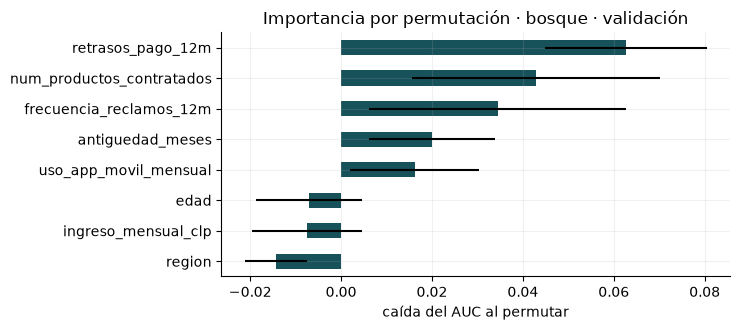

In [7]:
bosque = Pipeline([("preparar", mr.preprocesador(numericas, categoricas, escalar=False)),
                   ("modelo", RandomForestClassifier(n_estimators=300, min_samples_leaf=10, random_state=SEMILLA,
                                                     n_jobs=1))]).fit(Xe, ye)
perm = permutation_importance(bosque, Xv, yv, scoring="roc_auc", n_repeats=15, random_state=SEMILLA, n_jobs=1)
importancia = pd.DataFrame({"caída_media_AUC": perm.importances_mean, "desviación": perm.importances_std},
                           index=Xv.columns).sort_values("caída_media_AUC")
importancia["caída_media_AUC"].plot.barh(xerr=importancia["desviación"], color="#175159", figsize=(7.5, 3.4),
                                          title="Importancia por permutación · bosque · validación")
plt.xlabel("caída del AUC al permutar"); plt.tight_layout(); plt.show()

<a id="comparacion"></a>

## Comparación en validación: ordenar, separar y calibrar

- **ROC-AUC**: probabilidad de que un caso positivo reciba mayor puntaje que uno negativo.
- **AP** (precisión promedio): resume la curva precisión–recall; su referencia es la prevalencia.
- **KS**: máxima distancia entre las distribuciones acumuladas de puntaje de positivos y negativos (habitual en riesgo de crédito).
- **Gini** $=2\,\text{AUC}-1$.
- **Brier**: error cuadrático medio de las probabilidades; mide calidad probabilística, no solo orden.

In [8]:
candidatos = {"Línea base (prevalencia)": Pipeline([("preparar", mr.preprocesador(numericas, categoricas)),
                                                    ("modelo", DummyClassifier(strategy="prior"))]).fit(Xe, ye),
              "Logística": logistica, "Árbol (prof. 3)": arbol, "KNN escalado": knn_con_escala, "Bosque": bosque}
filas = []
for nombre, modelo in candidatos.items():
    p = modelo.predict_proba(Xv)[:, 1]
    fila = {"modelo": nombre, "AP": average_precision_score(yv, p), "Brier": mr.brier(yv, p)}
    fila.update(mr.ks_gini(yv, p) if np.ptp(p) > 0 else {"KS": 0.0, "AUC": .5, "Gini": 0.0})
    filas.append(fila)
comparacion = pd.DataFrame(filas).set_index("modelo")[["AUC", "Gini", "KS", "AP", "Brier"]]
display(comparacion.sort_values("AUC", ascending=False))
elegido = "Logística"
print(f"Se selecciona {elegido}: desempeño competitivo, probabilidades interpretables y explicación por variable.")

,AUC,Gini,KS,AP,Brier
modelo,,,,,
Logística,0.715,0.429,0.353,0.507,0.178
KNN escalado,0.691,0.382,0.312,0.435,0.184
Bosque,0.680,0.359,0.379,0.435,0.185
Árbol (prof. 3),0.640,0.281,0.219,0.366,0.195
Línea base (prevalencia),0.500,0,0,0.279,0.201


Se selecciona Logística: desempeño competitivo, probabilidades interpretables y explicación por variable.


**Lectura.** La regresión logística compite o supera al bosque y además es explicable: en datos con relaciones
mayoritariamente monótonas, un modelo simple bien especificado es difícil de superar. La comparación usa una sola
partición de validación; el notebook 05 estima la variabilidad con validación cruzada.

<a id="ranking"></a>

## Del puntaje a la campaña: ganancia acumulada y beneficio esperado

Un puntaje ordena clientes. La **tabla de lift por deciles** muestra la tasa de abandono en cada décimo de riesgo y
la proporción acumulada de abandonos capturados. El control evalúa contactar al $k\%$ de mayor riesgo con
supuestos **explícitos y editables**: valor del cliente retenido, costo de contacto y tasa de éxito de la oferta.

,casos,eventos,tasa,lift,captura_acumulada
grupo,,,,,
1,19,12,0.632,2.264,0.226
2,19,9,0.474,1.698,0.396
3,19,5,0.263,0.943,0.491
4,19,4,0.211,0.755,0.566
5,19,8,0.421,1.509,0.717
6,19,7,0.368,1.321,0.849
7,19,4,0.211,0.755,0.925
8,19,1,0.053,0.189,0.943
9,19,2,0.105,0.377,0.981


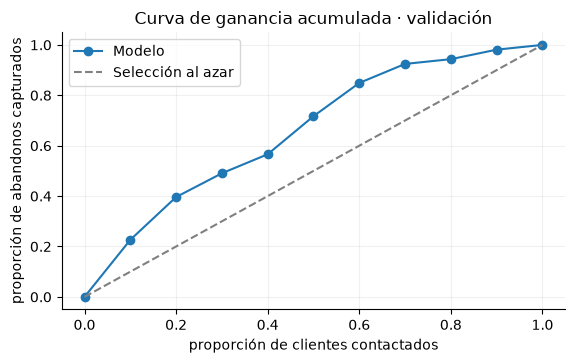

,campaña sobre 190 clientes de validación
clientes contactados,38
abandonos alcanzados,21
precisión de la lista,0.553
beneficio esperado modelo (miles CLP),"2,830"
beneficio esperado al azar (miles CLP),958


interactive(children=(IntSlider(value=20, description='% contactado', step=5), IntSlider(value=600, descriptio…

In [9]:
p_val = logistica.predict_proba(Xv)[:, 1]
lift = mr.lift_deciles(yv, p_val)
display(lift)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(np.r_[0, np.arange(1, 11) / 10], np.r_[0, lift["captura_acumulada"]], marker="o", label="Modelo")
ax.plot([0, 1], [0, 1], ls="--", color="grey", label="Selección al azar")
ax.set(xlabel="proporción de clientes contactados", ylabel="proporción de abandonos capturados",
       title="Curva de ganancia acumulada · validación"); ax.legend(); plt.show()

def explorar_campania(porcentaje_contactado=20, valor_cliente_miles=600, costo_contacto_miles=25, tasa_exito_pct=30):
    corte = np.quantile(p_val, 1 - porcentaje_contactado / 100) if porcentaje_contactado > 0 else np.inf
    contactar = p_val >= corte
    capturados = int(yv[contactar].sum()); n_contactos = int(contactar.sum())
    beneficio = capturados * tasa_exito_pct / 100 * valor_cliente_miles - n_contactos * costo_contacto_miles
    azar = yv.mean() * n_contactos * tasa_exito_pct / 100 * valor_cliente_miles - n_contactos * costo_contacto_miles
    resultado = pd.Series({"clientes contactados": n_contactos, "abandonos alcanzados": capturados,
                           "precisión de la lista": capturados / n_contactos if n_contactos else 0.0,
                           "beneficio esperado modelo (miles CLP)": beneficio,
                           "beneficio esperado al azar (miles CLP)": azar})
    display(resultado.to_frame(f"campaña sobre {len(yv)} clientes de validación"))
    return resultado

campania_base = explorar_campania()
widgets.interact(explorar_campania,
                 porcentaje_contactado=widgets.IntSlider(value=20, min=0, max=100, step=5, description="% contactado"),
                 valor_cliente_miles=widgets.IntSlider(value=600, min=100, max=2000, step=50, description="valor cliente"),
                 costo_contacto_miles=widgets.IntSlider(value=25, min=5, max=150, step=5, description="costo contacto"),
                 tasa_exito_pct=widgets.IntSlider(value=30, min=5, max=80, step=5, description="% éxito"));

**Lectura.** El beneficio depende tanto del modelo como de los supuestos: con baja tasa de éxito o alto costo de
contacto, conviene contactar menos clientes. Estos supuestos son de la gerencia comercial; el analista los hace
visibles y muestra la sensibilidad. Contactar al 100% equivale a no usar el modelo.

<a id="test-final"></a>

## Evaluación final en prueba

Con el modelo elegido y congelado se consulta la prueba una vez. Se informan ordenamiento (AUC, Gini, KS), calidad
probabilística (Brier) y la captura en el 20% de mayor riesgo.

In [10]:
p_prueba = logistica.predict_proba(Xt)[:, 1]
informe = mr.ks_gini(yt, p_prueba)
informe.update({"AP": average_precision_score(yt, p_prueba), "Brier": mr.brier(yt, p_prueba),
                "captura_20%": float(mr.lift_deciles(yt, p_prueba, grupos=5)["captura_acumulada"].iloc[0])})
display(pd.Series(informe).to_frame("prueba · logística"))

,prueba · logística
KS,0.392
AUC,0.728
Gini,0.455
AP,0.580
Brier,0.169
captura_20%,0.415


### Ejercicios resueltos

1. **Razón de chances.** Si $\beta=0{,}69$ para una variable binaria, $e^{0{,}69}\approx2$: las chances se duplican. Si la
   probabilidad base es 20% (chances 0,25), pasan a 0,5 y la probabilidad a $0{,}5/1{,}5\approx33\%$, no a 40%.
2. **KS y Gini.** Con AUC 0,78, Gini $=0{,}56$. Un KS de 0,45 indica que en algún punto de corte la proporción acumulada de
   no abandonos supera en 45 puntos a la de abandonos.
3. **Árbol frente a logística.** Si el regulador exige explicar cada rechazo, ¿qué conviene? Logística o árbol poco
   profundo, con documentación de variables y razones; un bosque requiere explicaciones adicionales.
4. **Campaña.** Con valor 600, éxito 30% y costo 25, contactar a un cliente vale la pena si su probabilidad de abandono
   supera $25/(0{,}3\cdot600)\approx0{,}14$. Es el mismo razonamiento de umbral que formaliza el notebook 05.

In [11]:
auto_04 = pregunta("Un modelo tiene AUC 0,80. ¿Qué afirmación es correcta?",
                   ["Clasifica bien 80% de los clientes",
                    "Un abandono elegido al azar recibe mayor puntaje que un no abandono elegido al azar con probabilidad 0,80",
                    "Sus probabilidades están calibradas"], 1,
                   "El AUC mide ordenamiento, no exactitud ni calibración.")
assert auc_knn["KNN con estandarización"] > auc_knn["KNN sin escalar"]
assert comparacion.loc["Logística", "AUC"] > comparacion.loc["Línea base (prevalencia)", "AUC"] + .15
assert abs(comparacion.loc["Logística", "Gini"] - (2 * comparacion.loc["Logística", "AUC"] - 1)) < 1e-12
assert campania_base["beneficio esperado modelo (miles CLP)"] > campania_base["beneficio esperado al azar (miles CLP)"]
print("Comprobaciones del laboratorio 04: OK")

Comprobaciones del laboratorio 04: OK


### Referencias

[James et al.: ISLP](https://www.statlearning.com/) (capítulos 4 y 8) ·
[scikit-learn: importancia por permutación](https://scikit-learn.org/stable/modules/permutation_importance.html) ·
Siddiqi, *Credit Risk Scorecards* (Wiley, 2006), para KS y Gini en puntajes de riesgo.